# Task 2

Implement the SeqScan clustering algorithm based on the pseudocode on page 16 of the
following paper: https://arxiv.org/pdf/1805.02102
Test your algorithm using one of the two options:
- Create a few small sample datasets manually (worth 1 point), or
- Generate your own synthetic dataset, similar to the example shown in Figure 12 of the
paper (worth 2 points).

In [1]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

TRANSITION = -1
LOCAL_NOISE = -2

## SeqScan implementation

In [2]:
@dataclass
class StayRegion:
    members: np.ndarray
    msr_members: np.ndarray
    presence: float

    @property
    def start(self):
        return int(self.members.min())

    @property
    def end(self):
        return int(self.members.max())


def dbscan(points, indices, epsilon, K):
    indices = np.asarray(indices, dtype=int)
    if len(indices) == 0:
        return []

    labels = DBSCAN(eps=epsilon, min_samples=K).fit_predict(points[indices])
    cluster_ids = sorted(set(labels) - {-1})
    return [np.sort(indices[labels == cluster_id]) for cluster_id in cluster_ids]

In [3]:
class SeqScan:
    def __init__(self, epsilon, K, delta):
        self.epsilon = epsilon
        self.K = int(K)
        self.delta = delta

    @staticmethod
    def presence(members, times):
        # Presence is the sum of durations of consecutive trajectory
        # observations that both belong to the cluster.
        members = np.sort(np.asarray(members, dtype=int))
        if len(members) < 2:
            return 0.0

        consecutive = np.diff(members) == 1
        durations = times[members[1:]] - times[members[:-1]]
        return float(durations[consecutive].sum())

    def findMSR(self, T, times, P):
        candidates = []
        for members in dbscan(T, P, self.epsilon, self.K):
            cluster_presence = self.presence(members, times)
            if cluster_presence >= self.delta:
                candidates.append((members, cluster_presence))

        if not candidates:
            return None

        # The trajectory is scanned from left to right, so this selects the
        # first qualifying cluster if several are created by one insertion.
        members, cluster_presence = min(
            candidates,
            key=lambda item: (item[0][-1], item[0][0], len(item[0])),
        )
        return StayRegion(
            members=members.copy(),
            msr_members=members.copy(),
            presence=cluster_presence,
        )

    def canExpand(self, activeStayRegion, i, T, times, C):
        if activeStayRegion is None:
            return False

        activeMembers = set(activeStayRegion.members.tolist())
        for members in dbscan(T, C, self.epsilon, self.K):
            overlapsActive = any(index in activeMembers for index in members)
            if i in members and overlapsActive:
                activeStayRegion.members = members.copy()
                activeStayRegion.presence = self.presence(members, times)
                return True

        return False

    def fit(self, T, times=None):
        T = np.asarray(T, dtype=float)
        if T.ndim != 2:
            raise ValueError("points must have shape (n_observations, n_dimensions)")

        n = len(T)
        if times is None:
            times = np.arange(n, dtype=float)
        times = np.asarray(times, dtype=float)

        if times.shape != (n,):
            raise ValueError("times must contain one timestamp per observation")
        if np.any(np.diff(times) <= 0):
            raise ValueError("times must be strictly increasing")

        stayRegionsSet = []
        C = []
        P = []
        activeStayRegion = None

        for i in range(n):
            C.append(i)

            if self.canExpand(activeStayRegion, i, T, times, C):
                P = []
                continue

            P.append(i)
            nextStayRegion = self.findMSR(T, times, P)

            if nextStayRegion is not None:
                if activeStayRegion is not None:
                    stayRegionsSet.append(activeStayRegion)
                activeStayRegion = nextStayRegion
                C = P.copy()
                P = []

        if activeStayRegion is not None:
            stayRegionsSet.append(activeStayRegion)

        labels = np.full(n, TRANSITION, dtype=int)
        for region_id, region in enumerate(stayRegionsSet):
            labels[region.members] = region_id

        # Unassigned points inside a stay region's temporal extent are local noise.
        for region in stayRegionsSet:
            extent = np.arange(region.start, region.end + 1)
            local_noise = extent[labels[extent] == TRANSITION]
            labels[local_noise] = LOCAL_NOISE

        self.points_ = T
        self.times_ = times
        self.stay_regions_ = stayRegionsSet
        self.labels_ = labels
        return self

    def fit_predict(self, T, times=None):
        return self.fit(T, times).labels_

## Synthetic dataset

The generated A-B-A-C movement is similar to Pattern 3 in Figure 12: the same spatial location A is visited in two nonconsecutive time intervals. It also includes sparse transitions and a short local excursion.

In [12]:
def generate_synthetic_trajectory():
    rng = np.random.default_rng()
    points = []
    expected_labels = []
    centers = {
        "A": np.array([0.0, 0.0]),
        "B": np.array([5.0, 0.3]),
        "C": np.array([2.5, 4.5]),
    }

    def add(values, label):
        points.extend(values)
        expected_labels.extend([label] * len(values))

    def stay(center, n):
        return rng.normal(center, 0.22, size=(n, 2))

    def transition(start, end, n):
        line = np.linspace(start, end, n + 2)[1:-1]
        return line + rng.normal(0, 0.04, size=line.shape)

    add(transition((-4, -3), centers["A"], 8), TRANSITION)
    add(stay(centers["A"], 24), 0)
    add(transition(centers["A"], (2.2, 2.0), 3), LOCAL_NOISE)
    add(transition((2.2, 2.0), centers["A"], 3), LOCAL_NOISE)
    add(stay(centers["A"], 18), 0)

    add(transition(centers["A"], centers["B"], 8), TRANSITION)
    add(stay(centers["B"], 42), 1)

    add(transition(centers["B"], centers["A"], 8), TRANSITION)
    add(stay(centers["A"], 38), 2)

    add(transition(centers["A"], centers["C"], 8), TRANSITION)
    add(stay(centers["C"], 40), 3)

    return (
        np.asarray(points),
        np.asarray(expected_labels),
        centers,
    )


points, expected_labels, expected_centers = generate_synthetic_trajectory()
times = np.arange(len(points), dtype=float)

print(f"observations: {len(points)}")

label_names = {
    TRANSITION: "transition",
    LOCAL_NOISE: "local noise",
    0: "stay A1",
    1: "stay B",
    2: "stay A2",
    3: "stay C",
}
point_counts = [np.sum(expected_labels == label) for label in label_names]


observations: 200


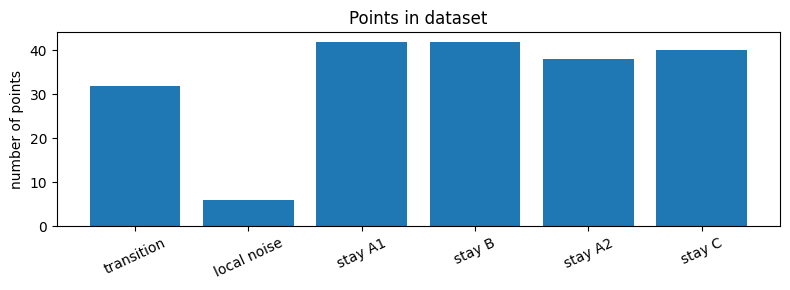

In [13]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(label_names.values(), point_counts)
ax.set_title("Points in dataset")
ax.set_ylabel("number of points")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

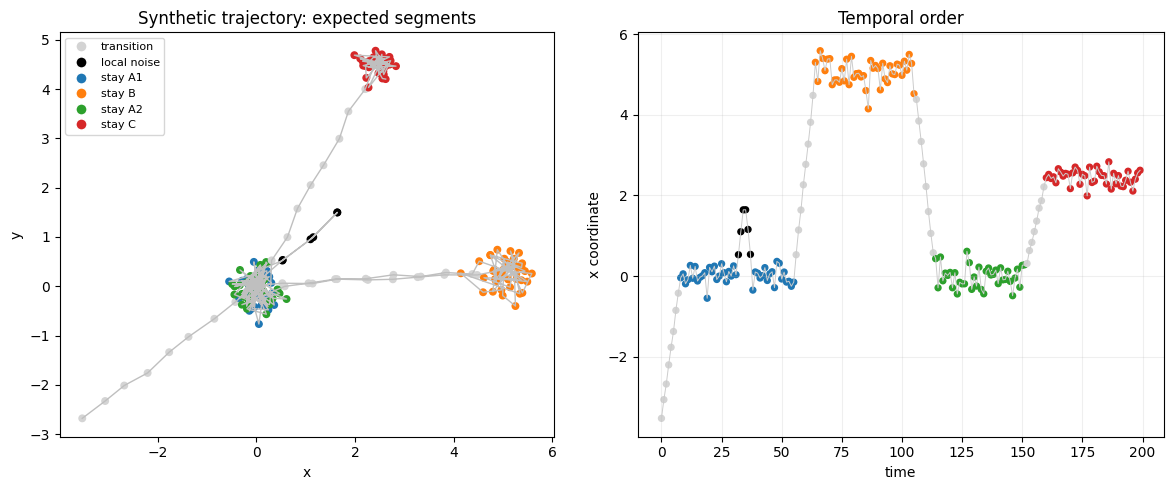

In [5]:
def label_colors(labels):
    tab10 = plt.get_cmap("tab10")
    colors = []
    for label in labels:
        if label == TRANSITION:
            colors.append((0.83, 0.83, 0.83, 1.0))
        elif label == LOCAL_NOISE:
            colors.append((0.0, 0.0, 0.0, 1.0))
        else:
            colors.append(tab10(label))
    return colors


legend = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="lightgray", label="transition", markersize=8),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", label="local noise", markersize=8),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=plt.get_cmap("tab10")(0), label="stay A1", markersize=8),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=plt.get_cmap("tab10")(1), label="stay B", markersize=8),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=plt.get_cmap("tab10")(2), label="stay A2", markersize=8),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=plt.get_cmap("tab10")(3), label="stay C", markersize=8),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(points[:, 0], points[:, 1], color="0.75", linewidth=1)
axes[0].scatter(points[:, 0], points[:, 1], c=label_colors(expected_labels), s=22)
axes[0].set_title("Synthetic trajectory: expected segments")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
axes[0].legend(handles=legend, loc="upper left", fontsize=8)

axes[1].scatter(times, points[:, 0], c=label_colors(expected_labels), s=18, label="x")
axes[1].plot(times, points[:, 0], color="0.8", linewidth=0.7)
axes[1].set_title("Temporal order")
axes[1].set_xlabel("time")
axes[1].set_ylabel("x coordinate")
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Run SeqScan

In [6]:
seqscan = SeqScan(
    epsilon=0.65,
    K=8,
    delta=12,
)
labels = seqscan.fit_predict(points, times)

region_rows = []
for region_id, region in enumerate(seqscan.stay_regions_):
    center = points[region.members].mean(axis=0)
    region_rows.append(
        {
            "region": region_id,
            "start": region.start,
            "end": region.end,
            "points": len(region.members),
            "presence": region.presence,
            "MSR start": int(region.msr_members.min()),
            "MSR end": int(region.msr_members.max()),
            "center x": center[0],
            "center y": center[1],
        }
    )

regions_df = pd.DataFrame(region_rows)
print("transitions:", np.sum(labels == TRANSITION))
print("local noise:", np.sum(labels == LOCAL_NOISE))
regions_df

transitions: 18
local noise: 4


,region,start,end,points,presence,MSR start,MSR end,center x,center y
0,0,6,57,48,46.0,6,18,0.039229,-0.075221
1,1,62,107,46,45.0,63,75,4.974428,0.260137
2,2,112,153,42,41.0,112,124,0.049272,0.011038
3,3,158,199,42,41.0,158,170,2.429454,4.461193


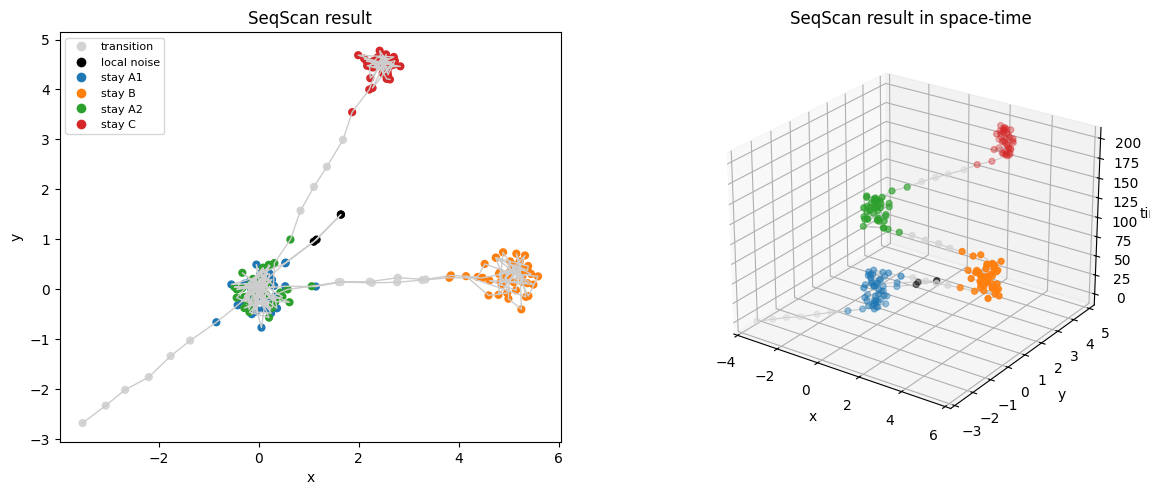

In [7]:
fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

ax1.plot(points[:, 0], points[:, 1], color="0.8", linewidth=1)
ax1.scatter(points[:, 0], points[:, 1], c=label_colors(labels), s=24)
ax1.set_title("SeqScan result")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_aspect("equal")
ax1.legend(handles=legend, loc="upper left", fontsize=8)

ax2.plot(points[:, 0], points[:, 1], times, color="0.8", linewidth=0.8)
ax2.scatter(points[:, 0], points[:, 1], times, c=label_colors(labels), s=18)
ax2.set_title("SeqScan result in space-time")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("time")
ax2.view_init(elev=25, azim=-55)

plt.tight_layout()
plt.show()

## Evaluation

In [8]:
expected_center_sequence = np.vstack([
    expected_centers["A"],
    expected_centers["B"],
    expected_centers["A"],
    expected_centers["C"],
])
detected_centers = regions_df[["center x", "center y"]].to_numpy()
center_errors = np.linalg.norm(detected_centers - expected_center_sequence, axis=1)

center_comparison = pd.DataFrame(
    {
        "region": np.arange(len(detected_centers)),
        "expected x": expected_center_sequence[:, 0],
        "expected y": expected_center_sequence[:, 1],
        "detected x": detected_centers[:, 0],
        "detected y": detected_centers[:, 1],
        "center error": center_errors,
    }
)

assert len(seqscan.stay_regions_) == 4
assert np.all(center_errors < 0.5)
assert np.linalg.norm(detected_centers[0] - detected_centers[2]) < 0.5
assert seqscan.stay_regions_[0].end < seqscan.stay_regions_[2].start
assert np.sum(labels == LOCAL_NOISE) > 0

center_comparison

,region,expected x,expected y,detected x,detected y,center error
0,0,0.0,0.0,0.039229,-0.075221,0.084836
1,1,5.0,0.3,4.974428,0.260137,0.047361
2,2,0.0,0.0,0.049272,0.011038,0.050494
3,3,2.5,4.5,2.429454,4.461193,0.080515


In [9]:
def broad_type(labels):
    return np.where(
        labels == TRANSITION,
        "transition",
        np.where(labels == LOCAL_NOISE, "local noise", "stay"),
    )


type_comparison = pd.crosstab(
    pd.Series(broad_type(expected_labels), name="expected"),
    pd.Series(broad_type(labels), name="SeqScan"),
)
type_comparison

SeqScan,local noise,stay,transition
expected,,,
local noise,4,2,0
stay,0,162,0
transition,0,14,18
